<a href="https://colab.research.google.com/github/SaraBatistaPereira/GSI073/blob/main/Untitled2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
A usar: cpu
A carregar o modelo: neuralmind/bert-base-portuguese-cased...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


A gerar embeddings para a coleção...
Matriz de embeddings gerada: (10, 768)
A executar t-SNE para visualização...


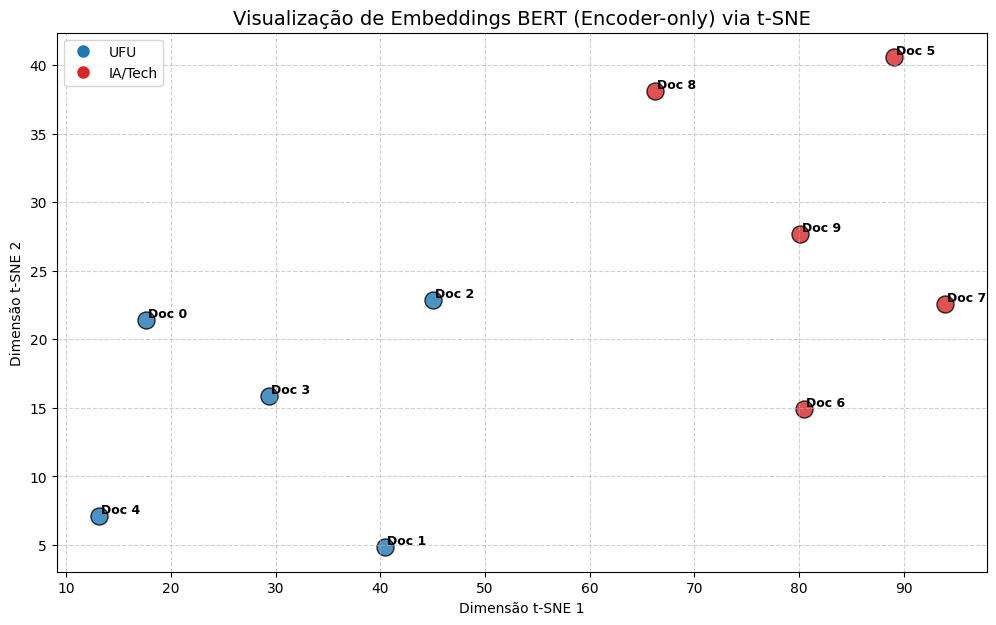

In [1]:
# ==============================================================================
# 1. INSTALAÇÃO E IMPORTAÇÕES
# ==============================================================================
!pip install -q transformers datasets accelerate matplotlib sklearn seaborn

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
from sklearn.manifold import TSNE
from datasets import Dataset

# Definir dispositivo (GPU se disponível)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"A usar: {device}")

# ==============================================================================
# 2. COLEÇÃO DE DOCUMENTOS (DATASET)
# ==============================================================================
# Criamos uma coleção mista para ver o t-SNE separar os temas
docs = [
    "A UFU é uma universidade federal localizada em Uberlândia.",
    "O Campus Santa Mônica da UFU é o principal centro administrativo.",
    "Estudantes da UFU fazem pesquisa de ponta em Minas Gerais.",
    "A Universidade Federal de Uberlândia possui diversos cursos de graduação.",
    "O vestibular da UFU é um dos mais concorridos do país.",
    "Modelos de IA baseados em Transformer mudaram o processamento de texto.",
    "O mecanismo de atenção permite ao modelo focar em palavras relevantes.",
    "Embeddings são representações vetoriais que capturam o significado semântico.",
    "Redes neurais profundas (Deep Learning) exigem GPUs potentes.",
    "O processamento de linguagem natural utiliza tensores multidimensionais."
]

# Labels apenas para a legenda do gráfico (0 = UFU/Educação, 1 = IA/Tecnologia)
labels = [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]

# ==============================================================================
# 3. CARREGAR MODELO ENCODER-ONLY (BERT PORTUGUÊS)
# ==============================================================================
# Usamos o modelo da NeuralMind que não exige autenticação (evita erro 401)
model_id = "neuralmind/bert-base-portuguese-cased"

print(f"A carregar o modelo: {model_id}...")
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModel.from_pretrained(model_id).to(device)

# ==============================================================================
# 4. EXTRAÇÃO DE EMBEDDINGS (TENSORES)
# ==============================================================================
def get_embeddings(text_list):
    model.eval()
    all_embeddings = []

    for text in text_list:
        # Tokenizar a frase
        inputs = tokenizer(text, return_tensors="pt", padding=True,
                           truncation=True, max_length=128).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            # O BERT gera um vetor para cada token.
            # Pegamos o token [CLS] (índice 0), que é o "resumo" da frase inteira.
            sentence_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(sentence_embedding[0])

    return np.array(all_embeddings)

print("A gerar embeddings para a coleção...")
embeddings_matrix = get_embeddings(docs)
print(f"Matriz de embeddings gerada: {embeddings_matrix.shape}") # (10 frases, 768 dimensões)

# ==============================================================================
# 5. REDUÇÃO DE DIMENSIONALIDADE (t-SNE) E PLOT
# ==============================================================================
# O t-SNE vai "esmagar" as 768 dimensões para apenas 2 (X e Y)
print("A executar t-SNE para visualização...")
tsne = TSNE(n_components=2, random_state=42, perplexity=5, init='pca', learning_rate='auto')
vis_dims = tsne.fit_transform(embeddings_matrix)

# Criar o gráfico
plt.figure(figsize=(12, 7))

# Definir cores para os grupos
colors = ['#1f77b4' if l == 0 else '#d62728' for l in labels]
categories = ["UFU / Institucional", "IA / Tecnologia"]

for i in range(len(vis_dims)):
    plt.scatter(vis_dims[i, 0], vis_dims[i, 1], c=colors[i], s=150, edgecolors='black', alpha=0.8)
    # Adicionar o texto (ID do documento) perto da bolinha
    plt.text(vis_dims[i, 0] + 0.2, vis_dims[i, 1] + 0.2, f"Doc {i}", fontsize=9, fontweight='bold')

# Estética do gráfico
plt.title("Visualização de Embeddings BERT (Encoder-only) via t-SNE", fontsize=14)
plt.xlabel("Dimensão t-SNE 1")
plt.ylabel("Dimensão t-SNE 2")

# Criar uma legenda manual
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='UFU', markerfacecolor='#1f77b4', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='IA/Tech', markerfacecolor='#d62728', markersize=10)]
plt.legend(handles=legend_elements, loc='best')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()